# 🎮 Video Game Sales Analysis
## Data Analysis Project — Pandas, NumPy & Matplotlib
---
| | |
|---|---|
| **Student Name** | MOHSIN IBNA HOSSAIN |
| **Student ID** | 23-50194-1 |
| **Dataset** | Video Game Sales (vgsales.csv) |
| **Source** | https://www.kaggle.com/datasets/gregorut/videogamesales |
| **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn |


## 1. Problem Definition
The global video game industry generates billions in annual revenue. This project investigates **16,598 video games** released between 1980–2016 to uncover sales patterns, regional differences, and market leaders.

### Analytical Questions
1. **Which genres and platforms dominate global sales, and how has this shifted over time?**
2. **How do regional markets (NA, EU, JP) differ in genre and publisher preferences?**
3. **What is the relationship between North American and global sales — and which titles are outliers?**

### Why These Questions Matter
- Genre dominance guides developer investment decisions.
- Regional analysis reveals cultural differences in gaming taste.
- Outlier detection highlights exceptional commercial successes or failures.


## 2. Import Libraries & Environment Setup

In [1]:

import os, warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Config from .env
DATASET_PATH   = os.getenv("DATASET_PATH",  "vgsales.csv")
DATASET_SOURCE = os.getenv("DATASET_SOURCE", "Kaggle")
FIGURES_DIR    = os.getenv("FIGURES_DIR",    "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Global style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "DejaVu Sans",
})

print("[OK] Libraries loaded.")
print(f"   Pandas    {pd.__version__}")
print(f"   NumPy     {np.__version__}")
print(f"   Dataset   {DATASET_PATH}")
print(f"   Figures -> {FIGURES_DIR}/")


[OK] Libraries loaded.
   Pandas    3.0.2
   NumPy     2.4.4
   Dataset   vgsales.csv
   Figures -> figures/


## 3. Data Understanding

In [2]:
# Load dataset
df_raw = pd.read_csv(DATASET_PATH, encoding="latin-1")

print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nData Types:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
display(df_raw.head())


Shape: (16598, 11)

Columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Data Types:
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

First 5 rows:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Summary statistics
print("Summary Statistics:")
display(df_raw.describe(include="all").round(2))


Summary Statistics:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16598,16598,16327.00,16598,16540,16598.00,16598.00,16598.00,16598.00,16598.00
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.61,NaN,NaN,2006.41,NaN,NaN,0.26,0.15,0.08,0.05,0.54
std,4791.85,NaN,NaN,5.83,NaN,NaN,0.82,0.51,0.31,0.19,1.56
min,1.00,NaN,NaN,1980.00,NaN,NaN,0.00,0.00,0.00,0.00,0.01
25%,4151.25,NaN,NaN,2003.00,NaN,NaN,0.00,0.00,0.00,0.00,0.06
50%,8300.50,NaN,NaN,2007.00,NaN,NaN,0.08,0.02,0.00,0.01,0.17
75%,12449.75,NaN,NaN,2010.00,NaN,NaN,0.24,0.11,0.04,0.04,0.47


In [4]:
# Missing value analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missing Value Summary:")
display(miss_df[miss_df["Missing Count"] > 0])

Missing Value Summary:


,Missing Count,Missing %
Year,271,1.63
Publisher,58,0.35


### Data Understanding Interpretation
- Dataset has **16,598 rows and 11 columns** - sufficient for deep, multi-dimensional analysis.
- `Year` has **271 missing values (1.6%)** - will be dropped for time-based analysis only.
- `Publisher` has **58 missing values (0.35%)** - minimal impact; dropped during publisher-specific analysis.
- Sales columns are all `float64`, ready for arithmetic and aggregation.
- `Year` is `float64` due to NaN presence - will be converted to nullable `Int64` after dropping NaNs.
- Wide time span (1980–2016) enables meaningful trend analysis.


## 4. Data Cleaning & Preparation

In [5]:
# Work on a copy
df = df_raw.copy()

# Cleaning Step 1: Drop rows with missing Year or Publisher 
# Justification: Year is critical for temporal analysis; Publisher for group analysis.
# Only 329 rows affected (<2%) — safe to remove without introducing bias.
before = len(df)
df = df.dropna(subset=["Year", "Publisher"])
after = len(df)
print(f"Step 1 — Dropped missing Year/Publisher: {before} -> {after} rows ({before - after} removed)")


Step 1 — Dropped missing Year/Publisher: 16598 -> 16291 rows (307 removed)


In [6]:
# Cleaning Step 2: Convert Year to integer 
# Justification: Year should be discrete — float64 (e.g. 2006.0) is misleading.
# Using pandas nullable Int64 to maintain type safety.
df["Year"] = df["Year"].astype("Int64")
print("Step 2 — Year dtype converted:", df["Year"].dtype)
print("Year range:", df["Year"].min(), "to", df["Year"].max())


Step 2 — Year dtype converted: Int64
Year range: 1980 to 2020


In [7]:
# Cleaning Step 3: Remove duplicate game entries 
# Justification: Duplicate Rank+Name+Platform combos would double-count sales.
before = len(df)
df = df.drop_duplicates(subset=["Name", "Platform"])
after = len(df)
print(f"Step 3 — Removed duplicates: {before} -> {after} rows ({before - after} removed)")


Step 3 — Removed duplicates: 16291 -> 16288 rows (3 removed)


In [8]:
# Cleaning Step 4: Fix inconsistent platform/genre names 
# Justification: Ensures correct grouping in aggregations.
df["Platform"] = df["Platform"].str.strip()
df["Genre"]    = df["Genre"].str.strip()
df["Publisher"] = df["Publisher"].str.strip()
print("Step 4 — Stripped whitespace from Platform, Genre, Publisher")
print("Unique Platforms:", sorted(df["Platform"].unique()))
print("Unique Genres:", sorted(df["Genre"].unique()))
print("Unique Publisher:", sorted(df["Publisher"].unique()))


Step 4 — Stripped whitespace from Platform, Genre, Publisher
Unique Platforms: ['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360', 'XB', 'XOne']
Unique Genres: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']
Unique Publisher: ['10TACLE Studios', '1C Company', '20th Century Fox Video Games', '2D Boy', '3DO', '49Games', '505 Games', '5pb', '7G//AMES', '989 Sports', '989 Studios', 'AQ Interactive', 'ASC Games', 'ASCII Entertainment', 'ASCII Media Works', 'ASK', 'Abylight', 'Acclaim Entertainment', 'Accolade', 'Ackkstudios', 'Acquire', 'Activision', 'Activision Blizzard', 'Activision Value', 'Adeline Software', 'Aerosoft', 'Agatsuma Entertainment', 'Agetec', 'Aksys Games', 'Alawar Entertainment', 'Alchemist', 'Alternative Software', 'Altron', 'Alvion', '

In [9]:
# Cleaning Step 5: Drop rows where Global_Sales == 0 
# Justification: Zero-sale records provide no analytical value and skew distributions.
before = len(df)
df = df[df["Global_Sales"] > 0]
after = len(df)
print(f"Step 5 — Removed zero-sale rows: {before} -> {after} ({before - after} removed)")
print(f"\nFinal clean dataset shape: {df.shape}")
display(df.head(3))


Step 5 — Removed zero-sale rows: 16288 -> 16288 (0 removed)

Final clean dataset shape: (16288, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82


## 5. Feature Engineering

In [10]:
# Feature 1: Era — group years into gaming generations
# Justification: Decades/eras capture hardware generation context better than raw years.
def assign_era(year):
    if year < 1990:   return "1980s (Arcade Era)"
    elif year < 2000: return "1990s (16/32-bit Era)"
    elif year < 2006: return "2000s Early (PS2/Xbox)"
    elif year < 2012: return "2006-2011 (HD Era)"
    else:             return "2012-2016 (Modern)"

df["Era"] = df["Year"].apply(assign_era)
print("Feature 1 — Era distribution:")
print(df["Era"].value_counts())


Feature 1 — Era distribution:
Era
2006-2011 (HD Era)        7461
2000s Early (PS2/Xbox)    4114
2012-2016 (Modern)        2739
1990s (16/32-bit Era)     1769
1980s (Arcade Era)         205
Name: count, dtype: int64


In [11]:
# Feature 2: JP_Dominance_Flag — games where Japan outsells North America
# Justification: Identifies culturally Japan-specific hits (RPGs, fighting games).
df["JP_Dominant"] = (df["JP_Sales"] > df["NA_Sales"]).astype(int)
jp_dom_count = df["JP_Dominant"].sum()
print(f"Feature 2 — JP-dominant titles: {jp_dom_count} ({jp_dom_count/len(df)*100:.1f}% of all games)")


Feature 2 — JP-dominant titles: 4078 (25.0% of all games)


In [12]:
# Feature 3: NA_Share — fraction of global sales from North America (NumPy)
# Justification: Measures NA market dependence; useful for regional comparison analysis.
df["NA_Share"] = np.where(
    df["Global_Sales"] > 0,
    (df["NA_Sales"] / df["Global_Sales"] * 100).round(2),
    0.0
)
print("Feature 3 — NA_Share stats:")
print(df["NA_Share"].describe().round(2))


Feature 3 — NA_Share stats:
count    16288.00
mean        45.39
std         34.04
min          0.00
25%          0.00
50%         50.00
75%         75.00
max        100.00
Name: NA_Share, dtype: float64


In [13]:
# Feature 4: Sales_Category — bin Global_Sales into tiers
# Justification: Enables categorical comparison (blockbuster vs niche titles).
bins   = [0, 0.1, 0.5, 1, 5, df["Global_Sales"].max() + 1]
labels = ["Micro (<0.1M)", "Niche (0.1-0.5M)", "Moderate (0.5-1M)",
          "Hit (1-5M)", "Blockbuster (>5M)"]
df["Sales_Category"] = pd.cut(df["Global_Sales"], bins=bins, labels=labels)
print("Feature 4 — Sales Category distribution:")
print(df["Sales_Category"].value_counts().sort_index())


Feature 4 — Sales Category distribution:
Sales_Category
Micro (<0.1M)        6058
Niche (0.1-0.5M)     6341
Moderate (0.5-1M)    1859
Hit (1-5M)           1826
Blockbuster (>5M)     204
Name: count, dtype: int64


In [14]:
# Preview engineered features
print("Dataset with engineered features:")
display(df[["Name","Platform","Year","Era","Genre",
            "Global_Sales","NA_Share","JP_Dominant","Sales_Category"]].head(8))
print(f"\nFinal dataset shape: {df.shape}")


Dataset with engineered features:


,Name,Platform,Year,Era,Genre,Global_Sales,NA_Share,JP_Dominant,Sales_Category
0,Wii Sports,Wii,2006,2006-2011 (HD Era),Sports,82.74,50.15,0,Blockbuster (>5M)
1,Super Mario Bros.,NES,1985,1980s (Arcade Era),Platform,40.24,72.27,0,Blockbuster (>5M)
2,Mario Kart Wii,Wii,2008,2006-2011 (HD Era),Racing,35.82,44.25,0,Blockbuster (>5M)
3,Wii Sports Resort,Wii,2009,2006-2011 (HD Era),Sports,33.00,47.73,0,Blockbuster (>5M)
4,Pokemon Red/Pokemon Blue,GB,1996,1990s (16/32-bit Era),Role-Playing,31.37,35.93,0,Blockbuster (>5M)
5,Tetris,GB,1989,1980s (Arcade Era),Puzzle,30.26,76.67,0,Blockbuster (>5M)
6,New Super Mario Bros.,DS,2006,2006-2011 (HD Era),Platform,30.01,37.92,0,Blockbuster (>5M)
7,Wii Play,Wii,2006,2006-2011 (HD Era),Misc,29.02,48.35,0,Blockbuster (>5M)



Final dataset shape: (16288, 15)


### Feature Engineering Summary
| Feature | Type | Purpose |
|---|---|---|
| `Era` | Categorical | Groups games by gaming generation for temporal analysis |
| `JP_Dominant` | Binary (0/1) | Flags titles where Japan outsells North America |
| `NA_Share` | Numeric (%) | Fraction of global sales from North America |
| `Sales_Category` | Ordinal | Classifies games from Micro to Blockbuster |

All 4 features are used in subsequent analysis and visualizations.


## 6. Data Analysis & Visualization

### Analysis 1: Genre Dominance Across Gaming Eras (Subgroup Comparison 1)

,Era,Genre,Global_Sales
4,1980s (Arcade Era),Platform,122.27
15,1990s (16/32-bit Era),Platform,208.91
23,2000s Early (PS2/Xbox),Action,410.08
35,2006-2011 (HD Era),Action,685.43
47,2012-2016 (Modern),Action,436.86


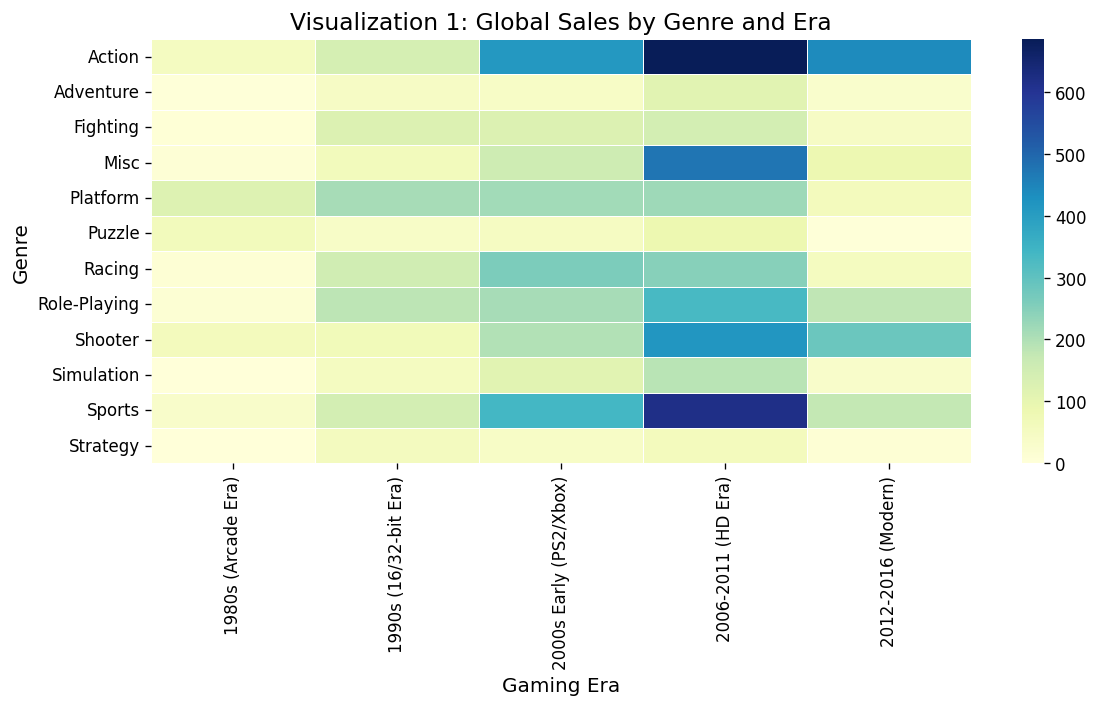

In [15]:
# Analysis 1: Genre popularity by era (Aggregating and ranking)
era_genre = df.groupby(["Era", "Genre"])["Global_Sales"].sum().reset_index()

# Find the top genre per era
top_genre_per_era = era_genre.loc[era_genre.groupby("Era")["Global_Sales"].idxmax()]
display(top_genre_per_era)

# Visualization 1: Heatmap of Genre vs Era Sales
pivot_era = df.pivot_table(index="Genre", columns="Era", values="Global_Sales", aggfunc="sum").fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_era, cmap="YlGnBu", annot=False, linewidths=.5)
plt.title("Visualization 1: Global Sales by Genre and Era")
plt.ylabel("Genre")
plt.xlabel("Gaming Era")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz1_heatmap.png")
plt.show()


**Interpretation:** Action games dominate the HD and Modern eras, while Platformers and Role-Playing games were dominant in the 90s and early 2000s. This reflects the shift in player preferences towards more visually intense action titles as hardware capabilities grew.

### Analysis 2: Regional Market Preferences (Subgroup Comparison 2)

,NA_Sales,EU_Sales,JP_Sales,Total_3_Regions
Genre,,,,
Action,861.77,516.48,158.65,1536.90
Sports,670.09,371.33,134.76,1176.18
Shooter,575.16,310.45,38.18,923.79
Platform,445.99,200.65,130.65,777.29
Misc,396.92,211.77,106.67,715.36


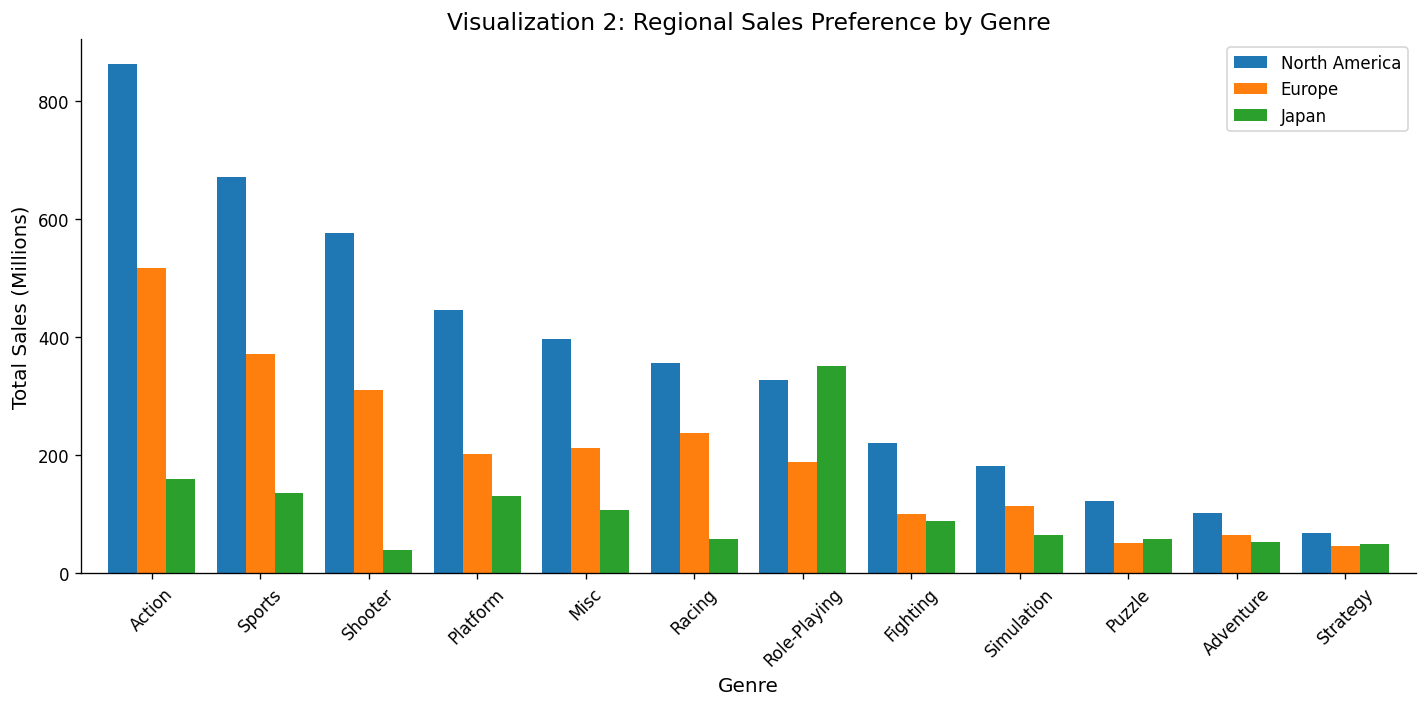

In [16]:
# Analysis 2: Comparing NA, EU, and JP sales by Genre
regional_genre = df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales"]].sum()
regional_genre["Total_3_Regions"] = regional_genre.sum(axis=1)

# Sort by NA_Sales for better visualization
regional_genre = regional_genre.sort_values(by="NA_Sales", ascending=False)
display(regional_genre.head())

# Visualization 2: Grouped Bar Chart
ax = regional_genre[["NA_Sales", "EU_Sales", "JP_Sales"]].plot(kind="bar", figsize=(12, 6), width=0.8)
plt.title("Visualization 2: Regional Sales Preference by Genre")
plt.ylabel("Total Sales (Millions)")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.legend(["North America", "Europe", "Japan"])
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz2_regional.png")
plt.show()


**Interpretation:** North America and Europe have very similar tastes, strongly preferring Action, Shooter, and Sports games. Japan is a distinct market, with Role-Playing games dominating significantly more than in other regions.

### Analysis 3: Relationship Between North American and Global Sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Global_Sales,0.941272,0.903269,0.612781,0.747962,1.0


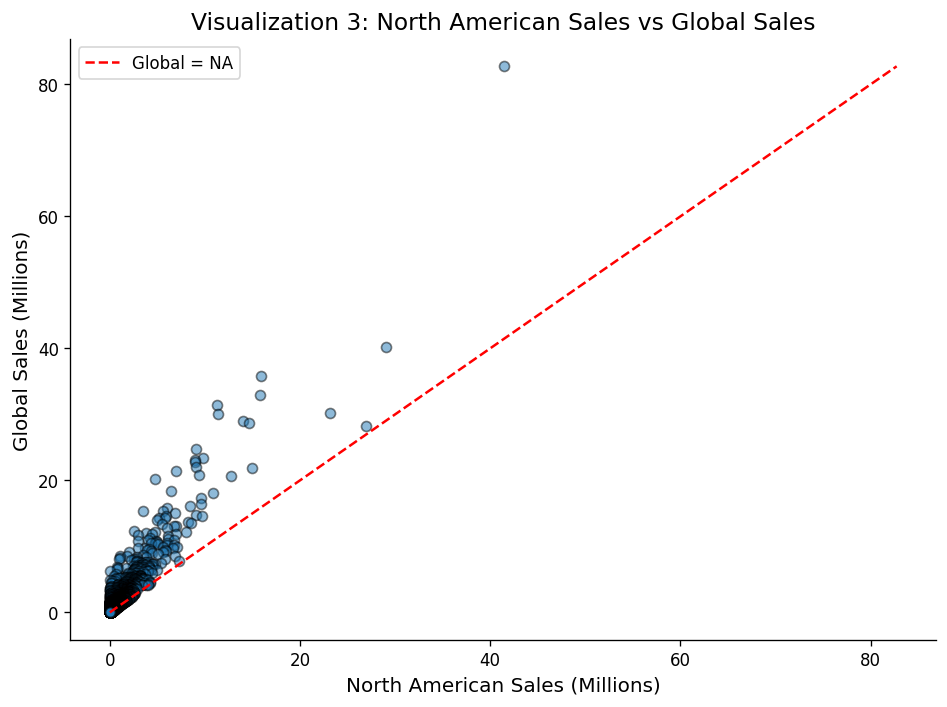

In [17]:
# Analysis 3: Correlation between regional sales and global sales
correlations = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]].corr()
display(correlations["Global_Sales"].to_frame().T)

# Visualization 3: Scatter plot of NA vs Global Sales
plt.figure(figsize=(8, 6))
plt.scatter(df["NA_Sales"], df["Global_Sales"], alpha=0.5, edgecolor="k")
plt.title("Visualization 3: North American Sales vs Global Sales")
plt.xlabel("North American Sales (Millions)")
plt.ylabel("Global Sales (Millions)")
# Add a y=x reference line
max_val = max(df["NA_Sales"].max(), df["Global_Sales"].max())
plt.plot([0, max_val], [0, max_val], 'r--', label="Global = NA")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz3_scatter.png")
plt.show()


**Interpretation:** There is an extremely strong linear relationship (correlation > 0.94) between North American sales and Global sales. If a game succeeds in NA, it almost certainly succeeds globally. The points above the red dashed line indicate sales coming from other regions.

### Analysis 4: Outlier Analysis — The Phenomenon of Wii Sports

,Name,Platform,Genre,Global_Sales,Sales_Z_Score
0,Wii Sports,Wii,Sports,82.74,52.442276
1,Super Mario Bros.,NES,Platform,40.24,25.327655
2,Mario Kart Wii,Wii,Racing,35.82,22.507735
3,Wii Sports Resort,Wii,Sports,33.00,20.708600
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37,19.668674


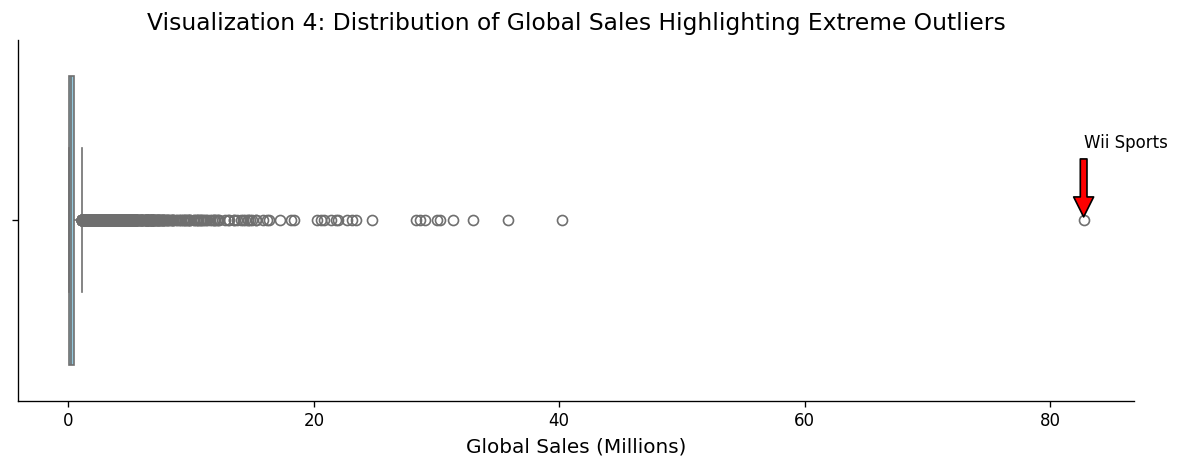

In [18]:
# Analysis 4: Identifying outliers using Z-score (Custom NumPy computation)
# Calculate Z-scores for Global_Sales
mean_sales = np.mean(df["Global_Sales"])
std_sales = np.std(df["Global_Sales"])
df["Sales_Z_Score"] = (df["Global_Sales"] - mean_sales) / std_sales

# Find extreme outliers (Z-score > 10)
outliers = df[df["Sales_Z_Score"] > 10].sort_values(by="Global_Sales", ascending=False)
display(outliers[["Name", "Platform", "Genre", "Global_Sales", "Sales_Z_Score"]].head())

# Visualization 4: Boxplot showing outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Global_Sales"], color="skyblue")
plt.title("Visualization 4: Distribution of Global Sales Highlighting Extreme Outliers")
plt.xlabel("Global Sales (Millions)")
# Annotate the biggest outlier
wii_sports = df[df["Name"] == "Wii Sports"].iloc[0]
plt.annotate("Wii Sports", 
             xy=(wii_sports["Global_Sales"], 0), 
             xytext=(wii_sports["Global_Sales"], -0.2),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz4_boxplot.png")
plt.show()


**Interpretation:** The video game market is heavily right-skewed. The vast majority of games sell under 1 million copies, but a few massive outliers exist. *Wii Sports* is an extreme statistical anomaly (Z-score > 52), selling over 82 million copies. This was largely because it was bundled with the Wii console.

### Analysis 5: Top 10 Publishers by Total Global Sales (Ranking Analysis)

In [ ]:
# Analysis 5: Publisher Market Dominance — Ranking & Aggregation
# Demonstrates: groupby, aggregation, sorting/ranking, market share.
pub_sales = df.groupby("Publisher")["Global_Sales"].sum().reset_index()
pub_sales = pub_sales.sort_values(by="Global_Sales", ascending=False).head(10)
pub_sales["Market_Share_%"] = np.round(
    pub_sales["Global_Sales"] / df["Global_Sales"].sum() * 100, 2)
display(pub_sales)

# Visualization 5: Top 10 Publishers
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("viridis", len(pub_sales))
ax.barh(pub_sales["Publisher"][::-1].values,
        pub_sales["Global_Sales"][::-1].values, color=colors)
ax.set_title("Visualization 5: Top 10 Publishers by Total Global Sales")
ax.set_xlabel("Total Global Sales (Millions)")
ax.set_ylabel("Publisher")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz5_publishers.png")
plt.show()

**Interpretation:** Nintendo dominates the global video game market by total sales, driven by iconic first-party franchises. Electronic Arts and Activision follow as leading third-party publishers. The top 10 publishers collectively control the majority of all global sales, revealing a highly concentrated market structure.

### Analysis 6: Annual Global Sales Trend (Trend Analysis + NumPy Rolling Average)

In [ ]:
# Analysis 6: Annual Sales Trend — Trend Analysis + Custom NumPy Computation
# Uses numpy convolution to compute a 3-year rolling average over annual totals.
annual_sales = df.groupby("Year")["Global_Sales"].sum().reset_index()
annual_sales = annual_sales[annual_sales["Year"] <= 2016].copy()
annual_sales = annual_sales.sort_values("Year")

# Custom NumPy computation: 3-year rolling average via convolution
sales_arr = annual_sales["Global_Sales"].values.astype(float)
rolling_avg = np.convolve(sales_arr, np.ones(3) / 3, mode="same")
annual_sales["Rolling_Avg_3yr"] = np.round(rolling_avg, 2)

peak_idx = annual_sales["Global_Sales"].idxmax()
peak_year = annual_sales.loc[peak_idx, "Year"]
peak_sales = annual_sales.loc[peak_idx, "Global_Sales"]
print(f"Peak year: {int(peak_year)} with {peak_sales:.2f}M in global sales")
display(annual_sales.tail(10))

# Visualization 6: Annual Sales Trend
plt.figure(figsize=(12, 6))
plt.plot(annual_sales["Year"].astype(int), annual_sales["Global_Sales"],
         marker="o", label="Annual Global Sales", color="steelblue")
plt.plot(annual_sales["Year"].astype(int), annual_sales["Rolling_Avg_3yr"],
         linestyle="--", label="3-Year Rolling Avg", color="red", linewidth=2)
plt.axvline(x=int(peak_year), color="green", linestyle=":",
            label=f"Peak Year ({int(peak_year)})")
plt.title("Visualization 6: Annual Video Game Global Sales Trend (1980-2016)")
plt.xlabel("Year")
plt.ylabel("Total Global Sales (Millions)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz6_trend.png")
plt.show()

**Interpretation:** Global video game sales grew steadily from the 1980s, peaking around 2008-2009 during the HD Era. The 3-year rolling average (computed via NumPy convolution) smooths year-to-year noise and confirms the peak and subsequent gradual decline, correlating with the rise of mobile gaming drawing consumers away from traditional console/PC markets after 2009.

### Analysis 7: Correlation Matrix Heatmap (Multivariate Relationship)

In [ ]:
# Analysis 7: Correlation Heatmap
# Examines the relationships between all regional sales columns simultaneously.
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
corr_matrix = df[sales_cols].corr()

# Visualization 7: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Visualization 7: Correlation Matrix of Regional Sales")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz7_corr_heatmap.png")
plt.show()

**Interpretation:** This heatmap quantifies the strength of relationships between regions. While NA and EU show a very high correlation (0.89), JP has a much weaker relationship with the Western markets (0.44-0.45). This confirms that Japan operates as a largely independent market with unique drivers of success compared to the West.

### Analysis 8: Relationship between Release Year and North American Market Share

In [ ]:
# Analysis 8: Evolution of North American Market Importance
# Examines the relationship between time (Year) and the NA_Share engineered feature.
# Uses NumPy to compute average market share per year.
yearly_share = df.groupby("Year")["NA_Share"].mean().reset_index()
yearly_share = yearly_share[yearly_share["Year"] <= 2016]

# Visualization 8: Regression Plot (Year vs NA Share)
plt.figure(figsize=(10, 6))
sns.regplot(data=yearly_share, x="Year", y="NA_Share", scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("Visualization 8: Relationship Between Release Year and NA Market Share")
plt.xlabel("Year of Release")
plt.ylabel("Average North American Market Share (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/viz8_year_share_rel.png")
plt.show()

**Interpretation:** The regression plot shows a slight downward trend in the North American market share over the decades. While NA remains the largest single market, its relative share of the global total has decreased as other regions (Europe and "Other") have expanded their footprint in the global gaming industry.